# Imports

In [86]:
import kagglehub
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import json
import pandas as pd
import random
import keras
from keras import layers
from keras import ops
from keras.layers import Conv2D, AvgPool2D, MaxPool2D, Dropout, Input, Flatten, Dense
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load in data

In [6]:
path = Path(kagglehub.dataset_download("barrettotte/resistors"))

In [7]:
os.listdir(path)

['4-band', '5-band', 'README.md', 'train.csv']

## Load in CSV

In [33]:
df = pd.read_csv(path / "train.csv")
df

,image,band_count,ohms,tolerance,watts,bands
0,4-band\4B-100K-T5\4B-100K-T5-1.jpg,4,100000.0,0.05,0.25,brown black yellow gold
1,4-band\4B-100K-T5\4B-100K-T5-10.jpg,4,100000.0,0.05,0.25,brown black yellow gold
2,4-band\4B-100K-T5\4B-100K-T5-2.jpg,4,100000.0,0.05,0.25,brown black yellow gold
3,4-band\4B-100K-T5\4B-100K-T5-3.jpg,4,100000.0,0.05,0.25,brown black yellow gold
4,4-band\4B-100K-T5\4B-100K-T5-4.jpg,4,100000.0,0.05,0.25,brown black yellow gold
...,...,...,...,...,...,...
1265,5-band\5B-9K1-T1\5B-9K1-T1-5.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1266,5-band\5B-9K1-T1\5B-9K1-T1-6.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1267,5-band\5B-9K1-T1\5B-9K1-T1-7.jpg,5,9100.0,0.01,0.25,white brown black brown brown
1268,5-band\5B-9K1-T1\5B-9K1-T1-8.jpg,5,9100.0,0.01,0.25,white brown black brown brown


## Load in 4 band data

In [22]:
with open(path / "4-band" / "4-band.json", "r") as file:
    four_band_json = json.load(file)

In [38]:
four_band_images = []

for folder in os.listdir(path / "4-band")[1:]:
    for image in os.listdir(path / "4-band" / folder):
        current_image = cv2.imread((path / "4-band" / folder / image), cv2.IMREAD_COLOR_RGB)
        index = df[df["image"].str.contains(fr"4-band\{folder}\{image}", regex=False)].index[0]
        four_band_images.append((index, current_image))

JSON

In [24]:
print(json.dumps(four_band_json, indent=4))

{
    "1": [
        "black",
        "brown",
        "black",
        "gold"
    ],
    "1.2": [
        "brown",
        "red",
        "gold",
        "gold"
    ],
    "1.5": [
        "brown",
        "green",
        "gold",
        "gold"
    ],
    "1.8": [
        "brown",
        "grey",
        "gold",
        "gold"
    ],
    "2.2": [
        "red",
        "red",
        "gold",
        "gold"
    ],
    "2.7": [
        "red",
        "violet",
        "gold",
        "gold"
    ],
    "3.3": [
        "orange",
        "orange",
        "gold",
        "gold"
    ],
    "3.9": [
        "orange",
        "white",
        "gold",
        "gold"
    ],
    "4.3": [
        "yellow",
        "orange",
        "gold",
        "gold"
    ],
    "4.7": [
        "yellow",
        "violet",
        "gold",
        "gold"
    ],
    "5.1": [
        "green",
        "brown",
        "gold",
        "gold"
    ],
    "5.6": [
        "green",
        "blue",
        "gold",
   

Example image

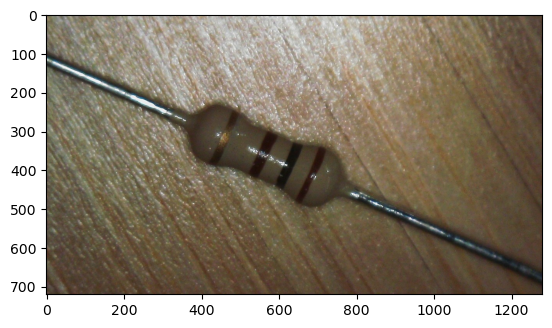

In [39]:
plt.imshow(four_band_images[10][1])

## Load in 5 band data

In [26]:
with open(path / "5-band" / "5-band.json", "r") as file:
    five_band_json = json.load(file)

In [46]:
five_band_images = []

for folder in os.listdir(path / "5-band")[1:]:
    for image in os.listdir(path / "5-band" / folder):
        current_image = cv2.imread((path / "5-band" / folder / image), cv2.IMREAD_COLOR_RGB)
        index = df[df["image"].str.contains(fr"5-band\{folder}\{image}", regex=False)].index[0]
        five_band_images.append((index, current_image))

JSON

In [27]:
print(json.dumps(five_band_json, indent=4))

{
    "1": [
        "brown",
        "black",
        "black",
        "silver",
        "brown"
    ],
    "1.5": [
        "brown",
        "green",
        "black",
        "silver",
        "brown"
    ],
    "2.2": [
        "red",
        "red",
        "black",
        "silver",
        "brown"
    ],
    "3.3": [
        "orange",
        "orange",
        "black",
        "silver",
        "brown"
    ],
    "4.7": [
        "yellow",
        "violet",
        "black",
        "silver",
        "brown"
    ],
    "5.1": [
        "green",
        "brown",
        "black",
        "silver",
        "brown"
    ],
    "10": [
        "brown",
        "black",
        "black",
        "gold",
        "brown"
    ],
    "20": [
        "red",
        "black",
        "black",
        "gold",
        "brown"
    ],
    "22": [
        "red",
        "red",
        "black",
        "gold",
        "brown"
    ],
    "33": [
        "orange",
        "orange",
        "black",
     

Example image

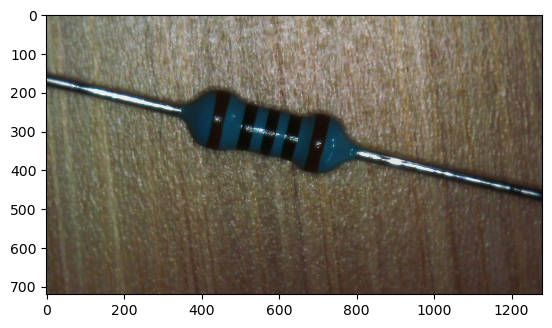

In [47]:
plt.imshow(five_band_images[10][1])

# Data split

In [69]:
merged_image_list = four_band_images + five_band_images
random.shuffle(merged_image_list)

In [77]:
indices_list, image_list = map(list, zip(*merged_image_list))

In [78]:
for i, image in enumerate(image_list):
    resized_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_LINEAR)
    scaled_image = resized_image.astype(np.float32) / 255.0
    image_list[i] = scaled_image

## Train Test Split

In [85]:
size = len(image_list)
train_size = int(0.8 * size)

train_images = image_list[:train_size]
train_indices = indices_list[:train_size]
train_labels = df.loc[train_indices, "ohms"].values

test_images = image_list[train_size:]
test_indices = indices_list[train_size:]
test_labels = df.loc[test_indices, "ohms"].values

## MinMax Scaling

In [ ]:
train_labels_log = np.log10(train_labels)
test_labels_log = np.log10(test_labels)

train_labels_log = train_labels.reshape(-1, 1)
test_labels_log = test_labels.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))

train_labels_scaled = scaler.fit_transform(train_labels_log)
test_labels_scaled = scaler.transform(test_labels_log)

# Models

In [89]:
base_model = keras.Sequential([
    Input((224, 224, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    AvgPool2D((2, 2), 1),
    Dropout(0.15),

    Conv2D(64, (5, 5), activation="relu"),
    AvgPool2D((2, 2), 1),
    Dropout(0.15),

    Conv2D(64, (3, 3), activation="relu"),
    AvgPool2D((2, 2), 1),
    Dropout(0.15),

    Flatten(),
    Dense(1)
])

base_model.compile(optimizer="Adam", loss="mse", metrics=["mse"])

In [90]:
model_dict = {"Base Model": base_model}

## Cross Validation

In [ ]:
def k_fold_cross_validation(model, X_train, y_train, K=5):
    subset_size = len(X_train) // K

    # Train model K times, using each subset as a "testing" set over iterations
    for i in range(K):
        current_X_test = X_train[subset_size * i: subset_size * (i + 1)]
        current_y_test = y_train[subset_size * i: subset_size * (i + 1)]

        

    